In [1]:
import sys
!{sys.executable} -m pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\yuril\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("retail_sales_dataset.csv")
df.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


In [4]:
df.shape

(1000, 9)

In [5]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [7]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

#### Transformacion de datos(para trabajar de manera formateada) 

In [8]:
df["Date"]= pd.to_datetime(df["Date"])
df["Month"]= df["Date"].dt.month
df["Year"]= df["Date"].dt.year 

#### Clasificar las ventas en Alta, Media y Baja
van aproximadamente desde 25 hasta 2000(se dejara valores alta media y baja a base de los datos que se menciono)


In [9]:
def clasificar_ventas(total):
    if total >= 1000:
        return "alta"
    elif total >= 500:
        return "media"
    else:
        return "baja"
    
df["Sales Category"] = df["Total Amount"].apply(clasificar_ventas)

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Year,Sales Category
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,2023,baja
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2,2023,alta
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,2023,baja
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5,2023,media
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5,2023,baja


#### Agrupación y agregación

In [10]:
ventas_por_categoria = df.groupby("Product Category")["Total Amount"].sum()
ventas_por_categoria

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

In [11]:
ventas_por_mes = df.groupby(["Product Category", "Month"])["Total Amount"].sum()
ventas_por_mes

Product Category  Month
Beauty            1        13930
                  2        14035
                  3        10545
                  4        11905
                  5        12450
                  6        10995
                  7        16090
                  8         9790
                  9         6320
                  10       15355
                  11        9700
                  12       12400
Clothing          1        13125
                  2        14560
                  3        15065
                  4        13940
                  5        17455
                  6        10170
                  7         8250
                  8        12455
                  9         9975
                  10       13315
                  11       15200
                  12       12070
Electronics       1         9925
                  2        15465
                  3         3380
                  4         8025
                  5        23245
                  6

In [12]:
ventas_por_year = df.groupby(["Product Category", "Year"])["Total Amount"].sum()
ventas_por_year

Product Category  Year
Beauty            2023    142015
                  2024      1500
Clothing          2023    155580
Electronics       2023    156875
                  2024        30
Name: Total Amount, dtype: int64

#### Estadísticas por categoria, funciones de agregación

In [13]:
estadisticas_categoria = df.groupby("Product Category")["Total Amount"].agg(["sum","mean","count","min","max","std","var"])

estadisticas_categoria

,sum,mean,count,min,max,std,var
Product Category,,,,,,,
Beauty,143515,467.475570,307,25,2000,563.612788,317659.374401
Clothing,155580,443.247863,351,25,2000,550.695917,303265.992674
Electronics,156905,458.786550,342,25,2000,567.540150,322101.822341


In [14]:
ventas_genero_categoria = df.groupby(["Gender", "Product Category"])["Total Amount"].agg(["sum","mean","count","min","max"])

ventas_genero_categoria

sum        mean  count  min   max
Gender Product Category                                     
Female Beauty            74830  450.783133    166   25  2000
       Clothing          81275  467.097701    174   25  2000
       Electronics       76735  451.382353    170   25  2000
Male   Beauty            68685  487.127660    141   25  2000
       Clothing          74305  419.802260    177   25  2000
       Electronics       80170  466.104651    172   25  2000

In [15]:
resumen_categoria_venta = df.groupby("Sales Category")["Total Amount"].agg(["sum","mean","count","min","max","std","var"])

resumen_categoria_venta

,sum,mean,count,min,max,std,var
Sales Category,,,,,,,
alta,286800,1419.801980,202,1000,2000,373.638770,139605.930742
baja,66900,102.923077,650,25,300,73.480458,5399.377741
media,102300,691.216216,148,500,900,181.800913,33051.571980


#### Análisis Personalizado con apply
Comparar cada venta con el promedio general

In [16]:
promedio_general = df["Total Amount"].mean()

promedio_general

np.float64(456.0)

In [17]:
def comparar_con_promedio(total):
    if total > promedio_general:
        return "Sobre el promedio"
    elif total < promedio_general:
        return "Bajo el promedio"
    else:
        return "Igual al promedio"

In [18]:
df["Comparison With Average"] = df["Total Amount"].apply(comparar_con_promedio)
df[["Total Amount", "Comparison With Average"]].head(10)

,Total Amount,Comparison With Average
0,150,Bajo el promedio
1,1000,Sobre el promedio
2,30,Bajo el promedio
3,500,Sobre el promedio
4,100,Bajo el promedio
5,30,Bajo el promedio
6,50,Bajo el promedio
7,100,Bajo el promedio
8,600,Sobre el promedio
9,200,Bajo el promedio


#### Desviación de cada venta respecto a la media de su grupo

In [19]:
df["Group Average"] = df.groupby("Product Category")["Total Amount"].transform("mean")
df["Deviation From Group Mean"] = df["Total Amount"] - df["Group Average"]
df[["Product Category", "Total Amount", "Group Average", "Deviation From Group Mean"]].head(10)

,Product Category,Total Amount,Group Average,Deviation From Group Mean
0,Beauty,150,467.475570,-317.475570
1,Clothing,1000,443.247863,556.752137
2,Electronics,30,458.786550,-428.786550
3,Clothing,500,443.247863,56.752137
4,Beauty,100,467.475570,-367.475570
5,Beauty,30,467.475570,-437.475570
6,Clothing,50,443.247863,-393.247863
7,Electronics,100,458.786550,-358.786550
8,Electronics,600,458.786550,141.213450
9,Clothing,200,443.247863,-243.247863


In [20]:
def interpretar_desviacion(valor):
    if valor > 0:
        return "Mayor que el promedio de su categoría"
    elif valor < 0:
        return "Menor que el promedio de su categoría"
    else:
        return "Igual al promedio de su categoría"
    
df["Deviation Analysis"] = df["Deviation From Group Mean"].apply(interpretar_desviacion)

df[["Product Category","Total Amount","Group Average","Deviation From Group Mean","Deviation Analysis"]].head(10)


,Product Category,Total Amount,Group Average,Deviation From Group Mean,Deviation Analysis
0,Beauty,150,467.475570,-317.475570,Menor que el promedio de su categoría
1,Clothing,1000,443.247863,556.752137,Mayor que el promedio de su categoría
2,Electronics,30,458.786550,-428.786550,Menor que el promedio de su categoría
3,Clothing,500,443.247863,56.752137,Mayor que el promedio de su categoría
4,Beauty,100,467.475570,-367.475570,Menor que el promedio de su categoría
5,Beauty,30,467.475570,-437.475570,Menor que el promedio de su categoría
6,Clothing,50,443.247863,-393.247863,Menor que el promedio de su categoría
7,Electronics,100,458.786550,-358.786550,Menor que el promedio de su categoría
8,Electronics,600,458.786550,141.213450,Mayor que el promedio de su categoría
9,Clothing,200,443.247863,-243.247863,Menor que el promedio de su categoría


#### Estadísticas descriptivas de columnas importantes

In [21]:
df[["Age", "Quantity", "Price per Unit", "Total Amount"]].describe()

,Age,Quantity,Price per Unit,Total Amount
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,41.39200,2.514000,179.890000,456.000000
std,13.68143,1.132734,189.681356,559.997632
min,18.00000,1.000000,25.000000,25.000000
25%,29.00000,1.000000,30.000000,60.000000
50%,42.00000,3.000000,50.000000,135.000000
75%,53.00000,4.000000,300.000000,900.000000
max,64.00000,4.000000,500.000000,2000.000000


#### Histograma de ventas totales

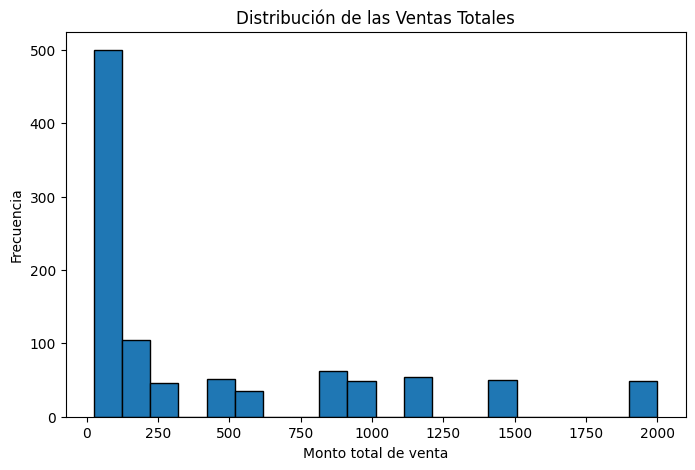

In [22]:
plt.figure(figsize=(8, 5))

plt.hist(df["Total Amount"], bins=20, edgecolor="black")

plt.title("Distribución de las Ventas Totales")
plt.xlabel("Monto total de venta")
plt.ylabel("Frecuencia")

plt.show()

#### Histograma de cantidad vendida

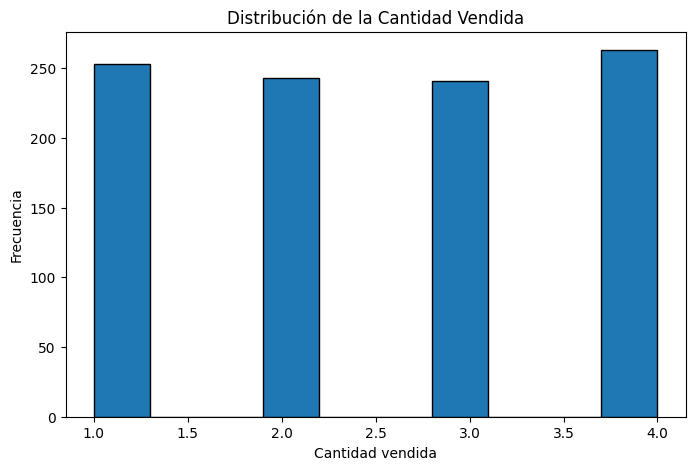

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(df["Quantity"], bins=10, edgecolor="black")

plt.title("Distribución de la Cantidad Vendida")
plt.xlabel("Cantidad vendida")
plt.ylabel("Frecuencia")

plt.show()

#### Boxplot de ventas totales

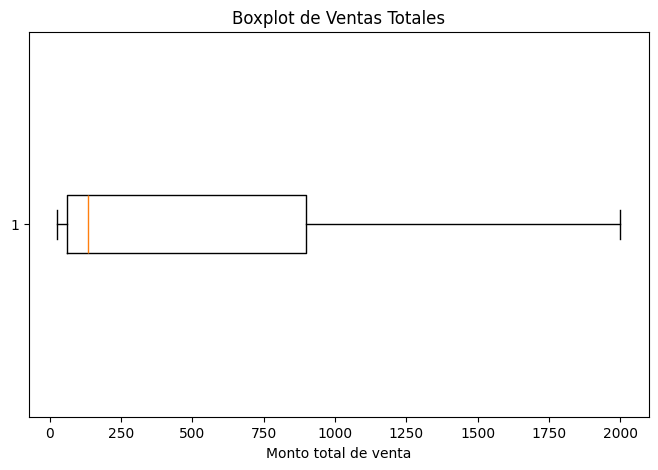

In [25]:
plt.figure(figsize=(8, 5))

plt.boxplot(df["Total Amount"], vert=False)

plt.title("Boxplot de Ventas Totales")
plt.xlabel("Monto total de venta")

plt.show()

#### Boxplot de precio por unidad

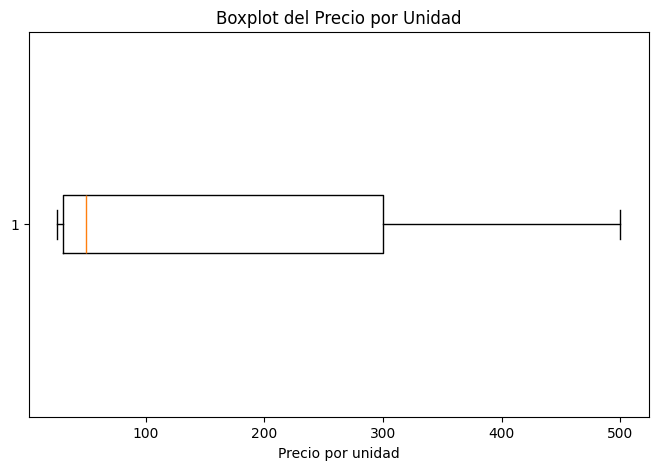

In [26]:
plt.figure(figsize=(8, 5))

plt.boxplot(df["Price per Unit"], vert=False)

plt.title("Boxplot del Precio por Unidad")
plt.xlabel("Precio por unidad")

plt.show()

#### Tendencia de ventas a lo largo del tiempo
Para observar la evolución de las ventas en el tiempo, se agrupan las ventas por fecha y luego se genera un gráfico de líneas.

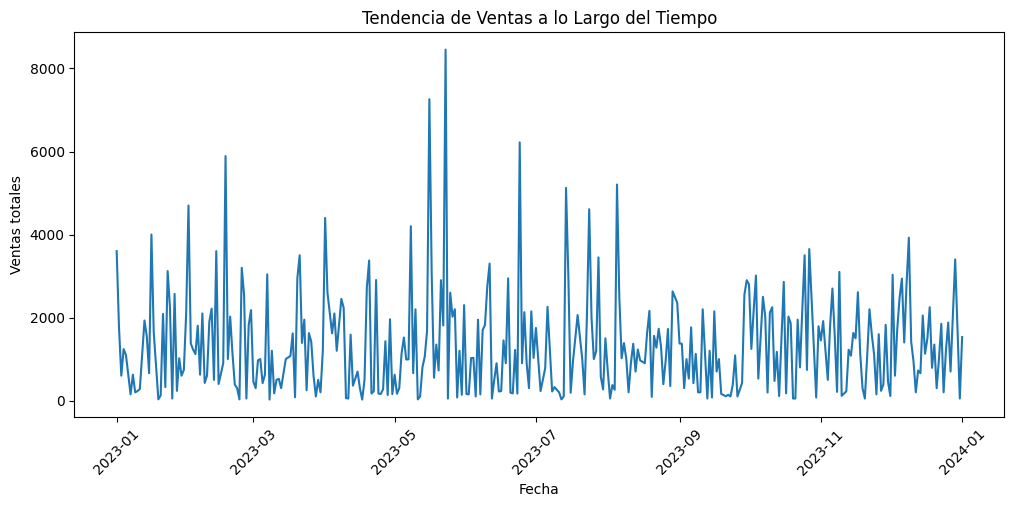

In [27]:
ventas_por_fecha = df.groupby("Date")["Total Amount"].sum()

ventas_por_fecha

plt.figure(figsize=(12, 5))

plt.plot(ventas_por_fecha.index, ventas_por_fecha.values)

plt.title("Tendencia de Ventas a lo Largo del Tiempo")
plt.xlabel("Fecha")
plt.ylabel("Ventas totales")

plt.xticks(rotation=45)

plt.show()

#### Ventas totales por mes

Este gráfico permite observar las ventas agrupadas por mes, de una forma más resumida que el gráfico por fecha.

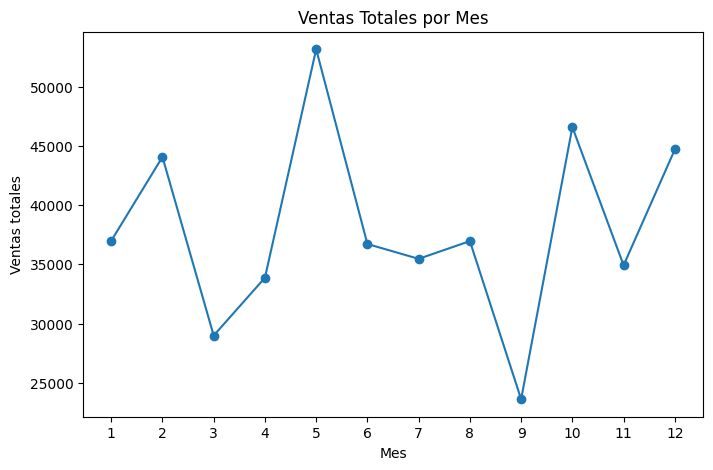

In [28]:
ventas_por_mes_general = df.groupby("Month")["Total Amount"].sum()

ventas_por_mes_general
plt.figure(figsize=(8, 5))

plt.plot(ventas_por_mes_general.index, ventas_por_mes_general.values, marker="o")

plt.title("Ventas Totales por Mes")
plt.xlabel("Mes")
plt.ylabel("Ventas totales")

plt.xticks(ventas_por_mes_general.index)

plt.show()

#### Ventas por categoría de producto

Este gráfico permite comparar el total de ventas generado por cada categoría de producto.

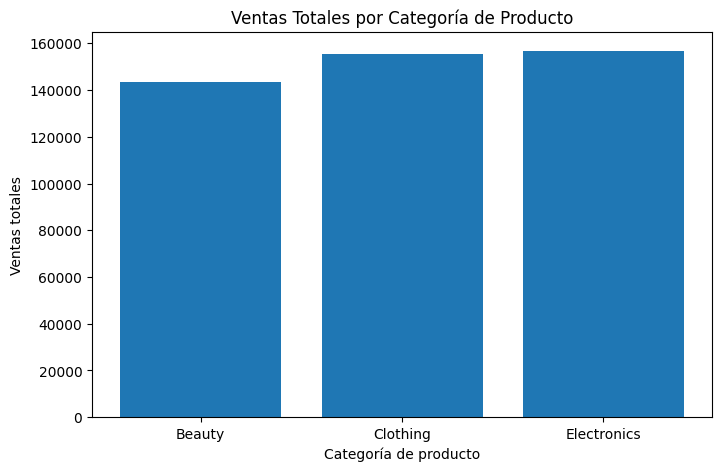

In [29]:
ventas_por_categoria = df.groupby("Product Category")["Total Amount"].sum()

ventas_por_categoria
plt.figure(figsize=(8, 5))

plt.bar(ventas_por_categoria.index, ventas_por_categoria.values)

plt.title("Ventas Totales por Categoría de Producto")
plt.xlabel("Categoría de producto")
plt.ylabel("Ventas totales")

plt.show()

#### Gráfico de dispersión: cantidad vendida y venta total

El gráfico de dispersión permite analizar la relación entre la cantidad vendida y el monto total de venta.


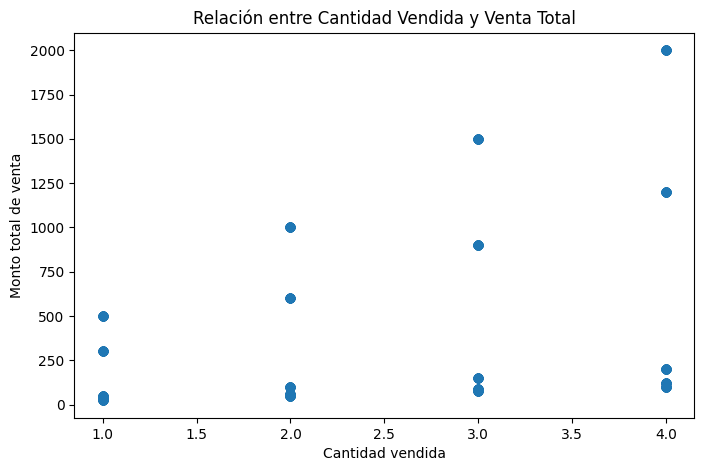

In [30]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Quantity"], df["Total Amount"])

plt.title("Relación entre Cantidad Vendida y Venta Total")
plt.xlabel("Cantidad vendida")
plt.ylabel("Monto total de venta")

plt.show()

#### Gráfico de dispersión: precio por unidad y venta total

Este gráfico permite analizar si existe una relación entre el precio por unidad y el monto total de venta.

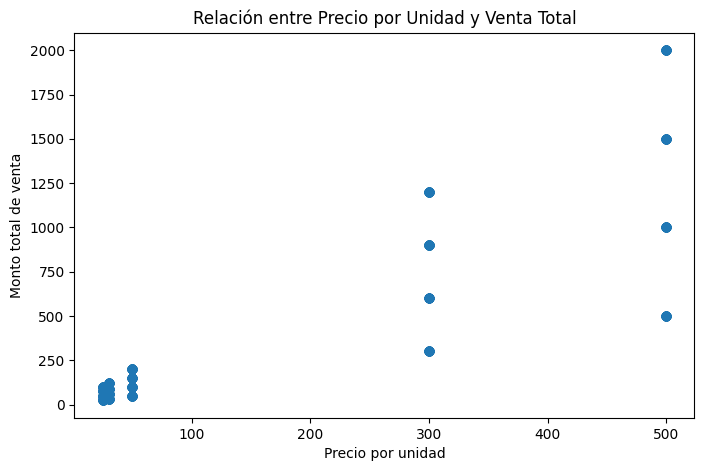

In [31]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Price per Unit"], df["Total Amount"])

plt.title("Relación entre Precio por Unidad y Venta Total")
plt.xlabel("Precio por unidad")
plt.ylabel("Monto total de venta")

plt.show()

#### Histograma y boxplot combinados

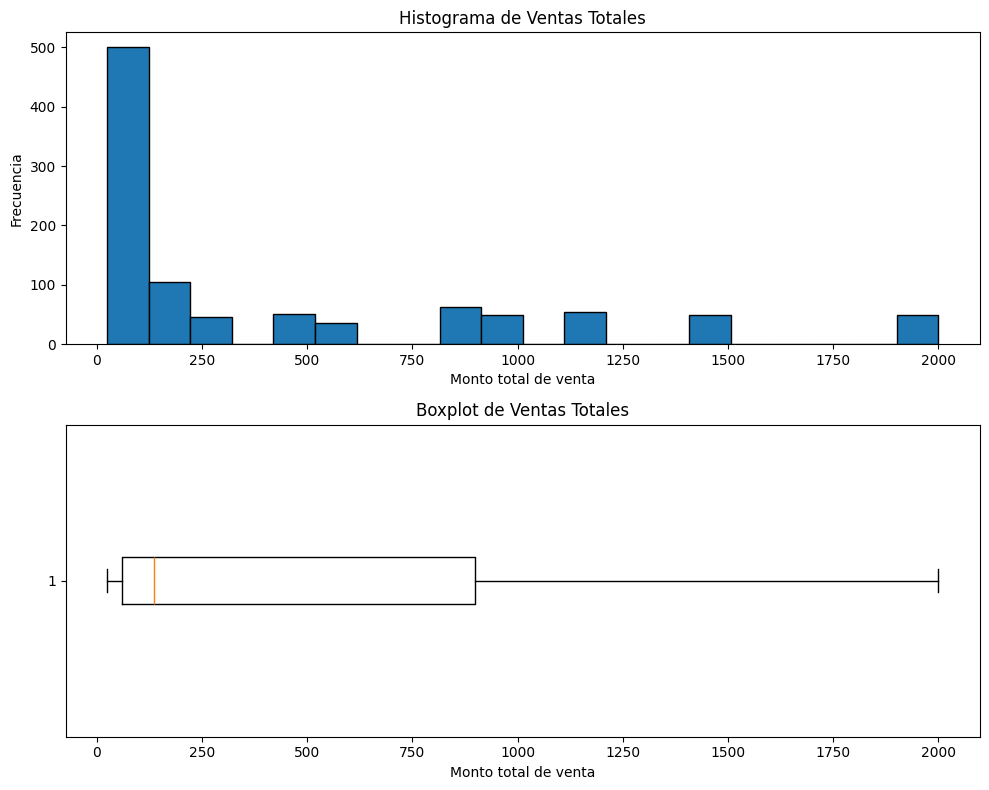

In [32]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.hist(df["Total Amount"], bins=20, edgecolor="black")
plt.title("Histograma de Ventas Totales")
plt.xlabel("Monto total de venta")
plt.ylabel("Frecuencia")

plt.subplot(2, 1, 2)
plt.boxplot(df["Total Amount"], vert=False)
plt.title("Boxplot de Ventas Totales")
plt.xlabel("Monto total de venta")

plt.tight_layout()

plt.show()

#### Cantidad de ventas por categoría

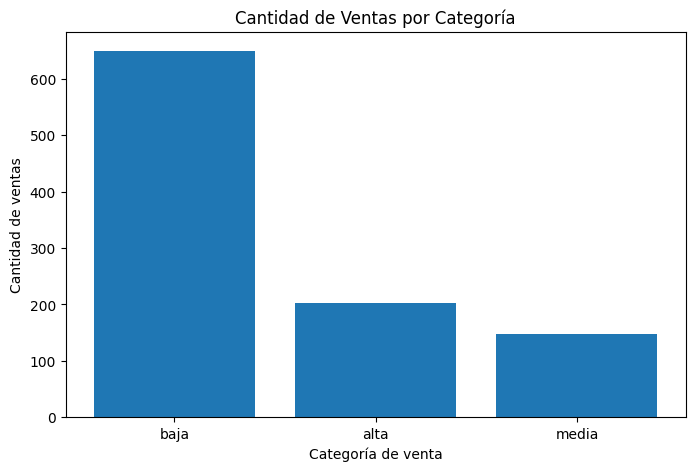

In [33]:
conteo_categorias = df["Sales Category"].value_counts()

conteo_categorias
plt.figure(figsize=(8, 5))

plt.bar(conteo_categorias.index, conteo_categorias.values)

plt.title("Cantidad de Ventas por Categoría")
plt.xlabel("Categoría de venta")
plt.ylabel("Cantidad de ventas")

plt.show()

In [34]:
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

In [35]:
columnas_numericas = ["Age", "Quantity", "Price per Unit", "Total Amount", "Month", "Year"]

correlacion = df[columnas_numericas].corr()

correlacion

,Age,Quantity,Price per Unit,Total Amount,Month,Year
Age,1.000000,-0.023737,-0.038423,-0.060568,-0.000640,0.023269
Quantity,-0.023737,1.000000,0.017501,0.373707,-0.021803,-0.020324
Price per Unit,-0.038423,0.017501,1.000000,0.851925,-0.008161,0.020097
Total Amount,-0.060568,0.373707,0.851925,1.000000,-0.005197,0.024714
Month,-0.000640,-0.021803,-0.008161,-0.005197,1.000000,-0.071981
Year,0.023269,-0.020324,0.020097,0.024714,-0.071981,1.000000


In [41]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\yuril\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


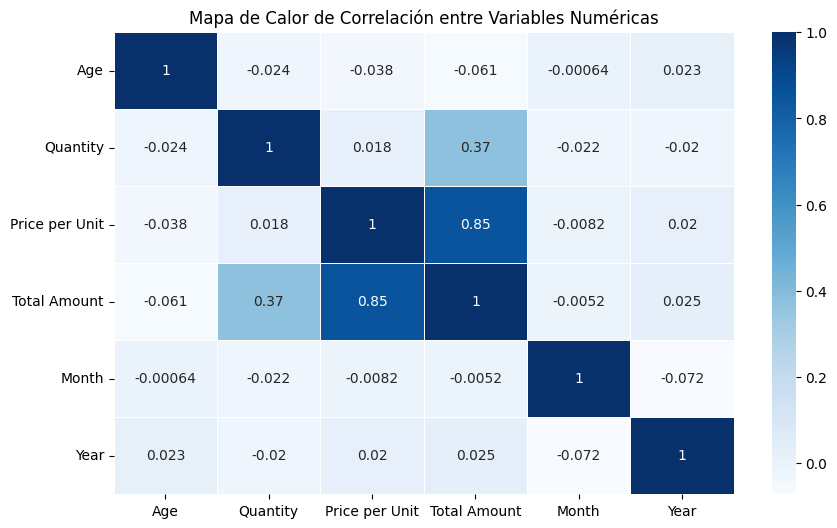

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlacion,
    annot=True,
    cmap="Blues",
    linewidths=0.5
)

plt.title("Mapa de Calor de Correlación entre Variables Numéricas")
plt.show()

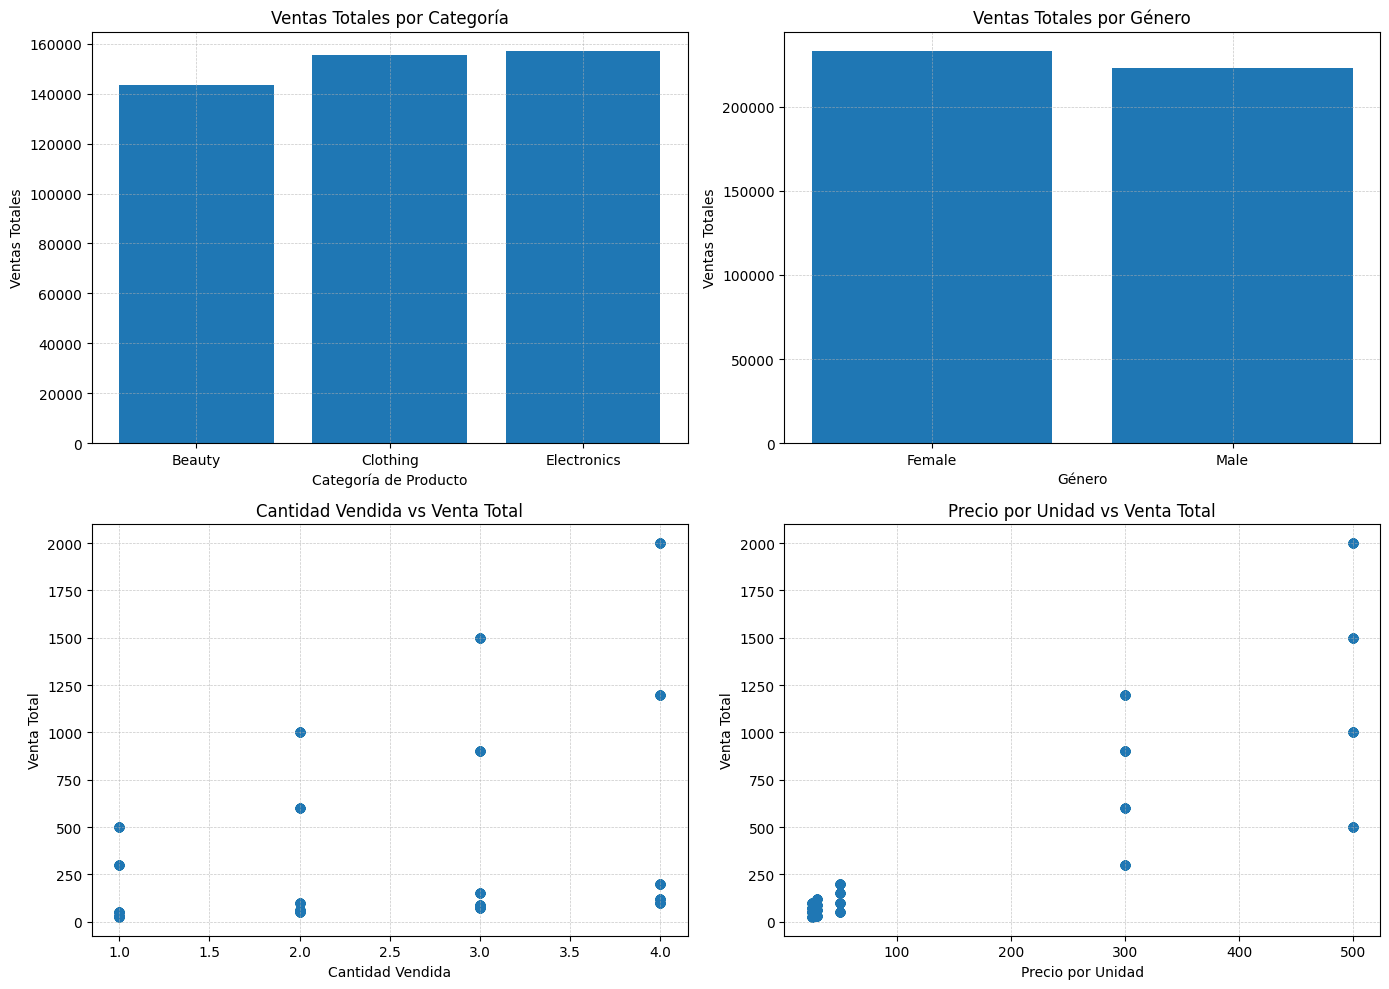

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Ventas por categoría
ventas_categoria = df.groupby("Product Category")["Total Amount"].sum()
axes[0, 0].bar(ventas_categoria.index, ventas_categoria.values)
axes[0, 0].set_title("Ventas Totales por Categoría")
axes[0, 0].set_xlabel("Categoría de Producto")
axes[0, 0].set_ylabel("Ventas Totales")
axes[0, 0].grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

# Ventas por género
ventas_genero = df.groupby("Gender")["Total Amount"].sum()
axes[0, 1].bar(ventas_genero.index, ventas_genero.values)
axes[0, 1].set_title("Ventas Totales por Género")
axes[0, 1].set_xlabel("Género")
axes[0, 1].set_ylabel("Ventas Totales")
axes[0, 1].grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

#Relación entre cantidad y venta total
axes[1, 0].scatter(df["Quantity"], df["Total Amount"], alpha=0.6)
axes[1, 0].set_title("Cantidad Vendida vs Venta Total")
axes[1, 0].set_xlabel("Cantidad Vendida")
axes[1, 0].set_ylabel("Venta Total")
axes[1, 0].grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

# Relación entre precio unitario y venta total
axes[1, 1].scatter(df["Price per Unit"], df["Total Amount"], alpha=0.6)
axes[1, 1].set_title("Precio por Unidad vs Venta Total")
axes[1, 1].set_xlabel("Precio por Unidad")
axes[1, 1].set_ylabel("Venta Total")
axes[1, 1].grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

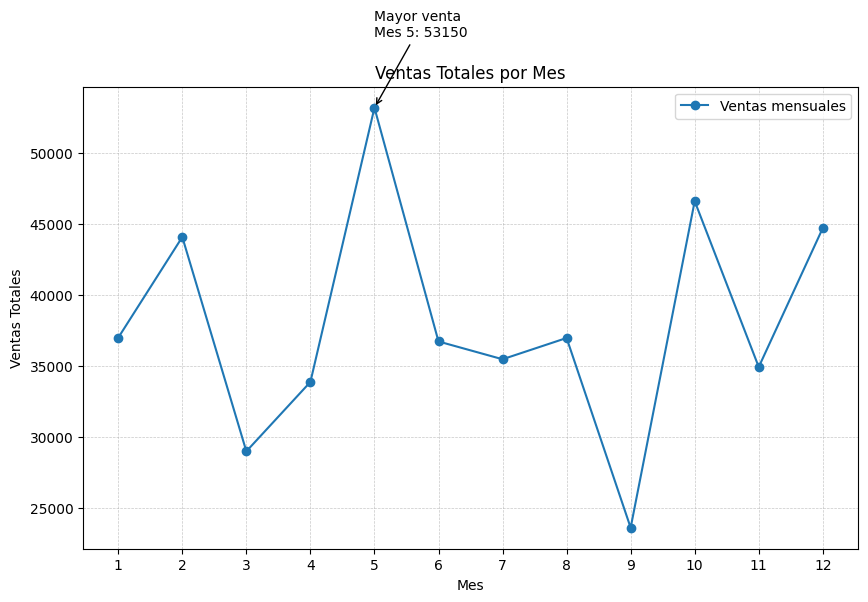

In [46]:
ventas_por_mes = df.groupby("Month")["Total Amount"].sum()

mes_mayor_venta = ventas_por_mes.idxmax()
mayor_venta = ventas_por_mes.max()

plt.figure(figsize=(10, 6))

plt.plot(
    ventas_por_mes.index,
    ventas_por_mes.values,
    marker="o",
    label="Ventas mensuales"
)

plt.title("Ventas Totales por Mes")
plt.xlabel("Mes")
plt.ylabel("Ventas Totales")

plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend()

plt.annotate(
    f"Mayor venta\nMes {mes_mayor_venta}: {mayor_venta}",
    xy=(mes_mayor_venta, mayor_venta),
    xytext=(mes_mayor_venta, mayor_venta + 5000),
    arrowprops=dict(facecolor="black", arrowstyle="->"),
    fontsize=10
)

plt.xticks(ventas_por_mes.index)
plt.show()

In [ ]:
#el mes con mayores ventas es:

ventas_por_mes.sort_values(ascending=False)

Month
5     53150
10    46580
12    44690
2     44060
1     36980
8     36960
6     36715
7     35465
11    34920
4     33870
3     28990
9     23620
Name: Total Amount, dtype: int64

#### Gráfico avanzado por categoría de producto

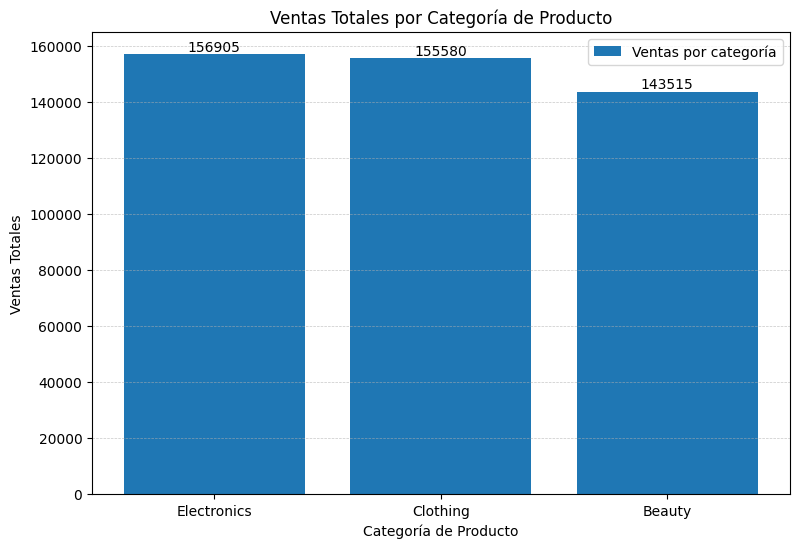

In [48]:
ventas_categoria = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 6))

barras = plt.bar(
    ventas_categoria.index,
    ventas_categoria.values,
    label="Ventas por categoría"
)

plt.title("Ventas Totales por Categoría de Producto")
plt.xlabel("Categoría de Producto")
plt.ylabel("Ventas Totales")
plt.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend()

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{int(altura)}",
        ha="center",
        va="bottom"
    )

plt.show()

#### Boxplot  por categoría

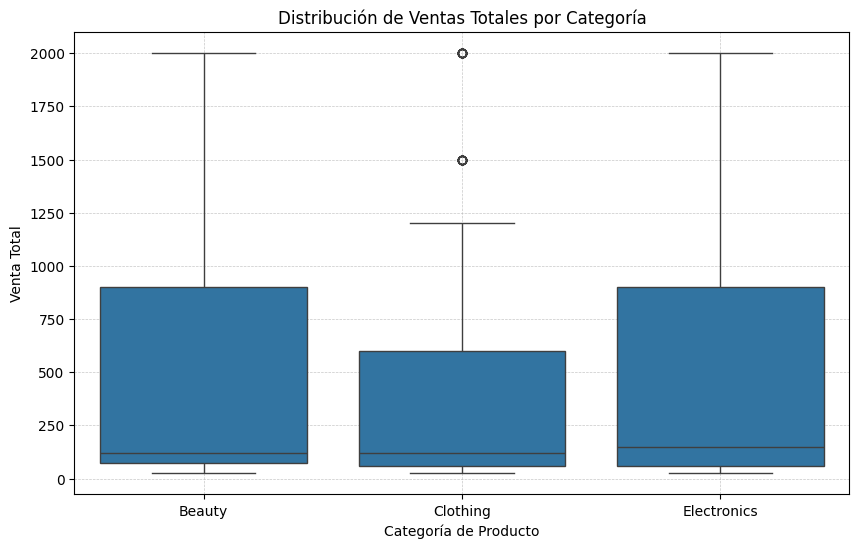

In [49]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Product Category",
    y="Total Amount"
)

plt.title("Distribución de Ventas Totales por Categoría")
plt.xlabel("Categoría de Producto")
plt.ylabel("Venta Total")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

plt.show()

#### Gráfico de dispersión con categorías y leyenda

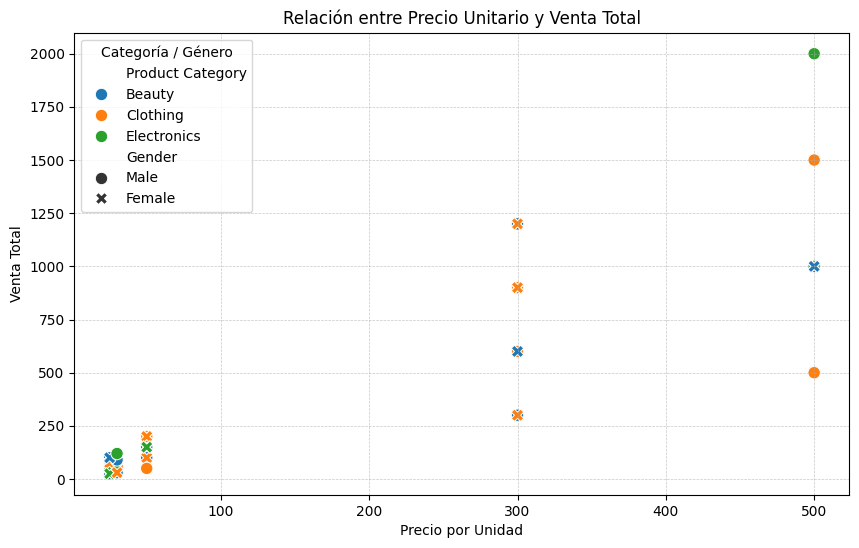

In [50]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Price per Unit",
    y="Total Amount",
    hue="Product Category",
    style="Gender",
    s=80
)

plt.title("Relación entre Precio Unitario y Venta Total")
plt.xlabel("Precio por Unidad")
plt.ylabel("Venta Total")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend(title="Categoría / Género")

plt.show()

#### Gráfico con flecha al valor máximo de venta

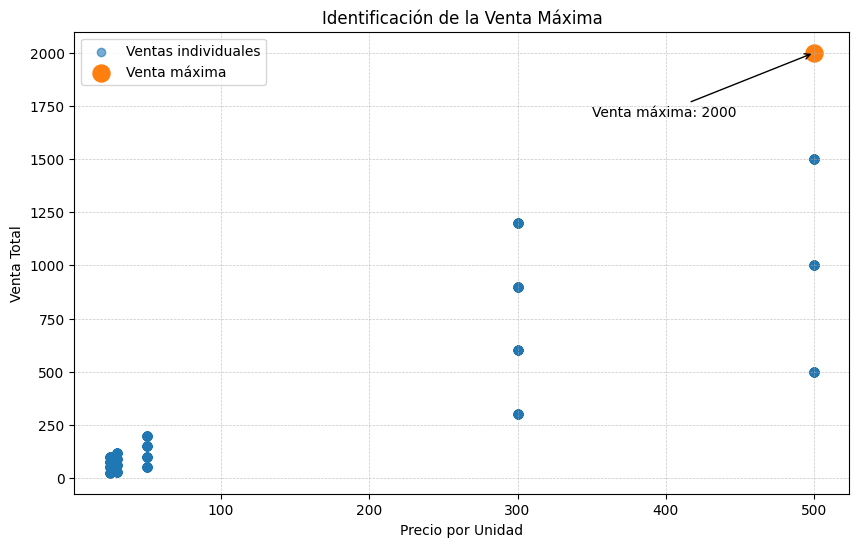

In [51]:
venta_maxima = df["Total Amount"].max()
fila_maxima = df[df["Total Amount"] == venta_maxima].iloc[0]

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Price per Unit"],
    df["Total Amount"],
    alpha=0.6,
    label="Ventas individuales"
)

plt.scatter(
    fila_maxima["Price per Unit"],
    fila_maxima["Total Amount"],
    s=150,
    label="Venta máxima"
)

plt.annotate(
    f"Venta máxima: {venta_maxima}",
    xy=(fila_maxima["Price per Unit"], fila_maxima["Total Amount"]),
    xytext=(fila_maxima["Price per Unit"] - 150, fila_maxima["Total Amount"] - 300),
    arrowprops=dict(facecolor="black", arrowstyle="->"),
    fontsize=10
)

plt.title("Identificación de la Venta Máxima")
plt.xlabel("Precio por Unidad")
plt.ylabel("Venta Total")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend()

plt.show()